# Test Trace Answer Visual-Index Analysis

Compare test accuracy when every mined `PATCH`/`REGION` action is replayed with either a random visual index or the final available visual index. Each trace is evaluated by the model that mined it.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd
from IPython.display import display

ROOT = next(
    (candidate for candidate in (Path.cwd(), *Path.cwd().parents) if (candidate / "scripts/eval_mined_traces_m3cot.py").exists()),
    Path.cwd(),
)

RESULTS_ROOT = ROOT / "outputs/inference/test_oracle_visual_index"
MODELS = ("ivtlr", "lvar")
CONTEXTS = ("global", "coarse")
INDEX_MODES = ("random", "last")
RESULTS_ROOT

PosixPath('/home/csalt/Haider/DVLM/lvar/outputs/inference/test_oracle_visual_index')

In [2]:
def prediction_path(model: str, context: str, index_mode: str) -> Path:
    run_dir = (
        RESULTS_ROOT
        / f"mined_by_{model}_ckpt"
        / f"evaluated_by_{model}_ckpt"
        / f"context_{context}"
        / f"visual_index_mode_{index_mode}"
    )
    return run_dir / f"m3cot_test_predictions_mined-by_{model}_evaluated-by_{model}_{context}_raw_{index_mode}.jsonl"


def read_jsonl(path: Path) -> list[dict]:
    with path.open(encoding="utf-8") as handle:
        return [json.loads(line) for line in handle if line.strip()]


records = []
for model in MODELS:
    for context in CONTEXTS:
        for index_mode in INDEX_MODES:
            path = prediction_path(model, context, index_mode)
            if not path.exists():
                records.append({
                    "model": model.upper(),
                    "context": context,
                    "visual_index_mode": index_mode,
                    "correct": None,
                    "total": 0,
                    "accuracy": None,
                    "status": "missing",
                    "path": str(path),
                })
                continue

            rows = read_jsonl(path)
            correct = sum(bool(row.get("correct")) for row in rows)
            total = len(rows)
            records.append({
                "model": model.upper(),
                "context": context,
                "visual_index_mode": index_mode,
                "correct": correct,
                "total": total,
                "accuracy": correct / total if total else None,
                "status": "complete" if total else "empty",
                "path": str(path),
            })

results = pd.DataFrame(records)
display(results.style.format({"accuracy": "{:.2%}"}))

,model,context,visual_index_mode,correct,total,accuracy,status,path
0,IVTLR,global,random,1538,2318,66.35%,complete,/home/csalt/Haider/DVLM/lvar/outputs/inference/test_oracle_visual_index/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/context_global/visual_index_mode_random/m3cot_test_predictions_mined-by_ivtlr_evaluated-by_ivtlr_global_raw_random.jsonl
1,IVTLR,global,last,1533,2318,66.13%,complete,/home/csalt/Haider/DVLM/lvar/outputs/inference/test_oracle_visual_index/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/context_global/visual_index_mode_last/m3cot_test_predictions_mined-by_ivtlr_evaluated-by_ivtlr_global_raw_last.jsonl
2,IVTLR,coarse,random,1038,2318,44.78%,complete,/home/csalt/Haider/DVLM/lvar/outputs/inference/test_oracle_visual_index/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/context_coarse/visual_index_mode_random/m3cot_test_predictions_mined-by_ivtlr_evaluated-by_ivtlr_coarse_raw_random.jsonl
3,IVTLR,coarse,last,1016,2318,43.83%,complete,/home/csalt/Haider/DVLM/lvar/outputs/inference/test_oracle_visual_index/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/context_coarse/visual_index_mode_last/m3cot_test_predictions_mined-by_ivtlr_evaluated-by_ivtlr_coarse_raw_last.jsonl
4,LVAR,global,random,1461,2318,63.03%,complete,/home/csalt/Haider/DVLM/lvar/outputs/inference/test_oracle_visual_index/mined_by_lvar_ckpt/evaluated_by_lvar_ckpt/context_global/visual_index_mode_random/m3cot_test_predictions_mined-by_lvar_evaluated-by_lvar_global_raw_random.jsonl
5,LVAR,global,last,1407,2318,60.70%,complete,/home/csalt/Haider/DVLM/lvar/outputs/inference/test_oracle_visual_index/mined_by_lvar_ckpt/evaluated_by_lvar_ckpt/context_global/visual_index_mode_last/m3cot_test_predictions_mined-by_lvar_evaluated-by_lvar_global_raw_last.jsonl
6,LVAR,coarse,random,965,2318,41.63%,complete,/home/csalt/Haider/DVLM/lvar/outputs/inference/test_oracle_visual_index/mined_by_lvar_ckpt/evaluated_by_lvar_ckpt/context_coarse/visual_index_mode_random/m3cot_test_predictions_mined-by_lvar_evaluated-by_lvar_coarse_raw_random.jsonl
7,LVAR,coarse,last,954,2318,41.16%,complete,/home/csalt/Haider/DVLM/lvar/outputs/inference/test_oracle_visual_index/mined_by_lvar_ckpt/evaluated_by_lvar_ckpt/context_coarse/visual_index_mode_last/m3cot_test_predictions_mined-by_lvar_evaluated-by_lvar_coarse_raw_last.jsonl


## Accuracy by setting

In [3]:
accuracy_table = results.pivot_table(
    index=["model", "context"],
    columns="visual_index_mode",
    values="accuracy",
    aggfunc="first",
    dropna=False,
).reindex(columns=list(INDEX_MODES))
accuracy_table.columns.name = "visual index mode"
display(accuracy_table.style.format("{:.2%}").highlight_max(axis=1, color="#d8f3dc"))

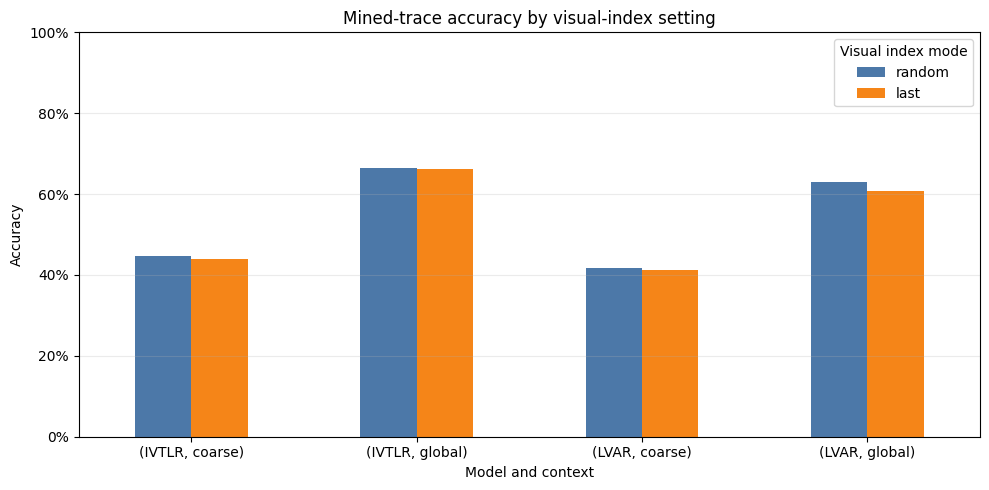

In [4]:
plot_data = accuracy_table.dropna(how="all")
if plot_data.empty:
    print(f"No completed visual-index results found under {RESULTS_ROOT}")
else:
    ax = plot_data.plot(kind="bar", figsize=(10, 5), rot=0, color=["#4C78A8", "#F58518"])
    ax.set_title("Mined-trace accuracy by visual-index setting")
    ax.set_xlabel("Model and context")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.legend(title="Visual index mode")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

## Missing or empty runs

In [ ]:
incomplete = results[results["status"] != "complete"]
if incomplete.empty:
    print("All eight expected runs are available.")
else:
    display(incomplete[["model", "context", "visual_index_mode", "status", "path"]])